# Henry's Tutorial for TOAST Part II

Date: 03 September 2026

---

This is Part II of Henry's TOAST tutorial which will cover a basic pipeline of simulated TOD to maps. 

In [1]:
import numpy as np
import astropy.units as u
from astropy.table import QTable
import pandas as pd
import os
import matplotlib.pyplot as plt

import healpy as hp
# from healpy.fitsfunc import read_map
# from healpy.visufunc import mollview, gnomview

out_dir = 'out_sim_ground'

Load the output maps created during Part I.

For this we can use the builtin healpy function `read_map`

In [2]:
# Helper functions to plot all the maps

def plot_maps(
    root,
    range_I=(-0.01, 0.01),
    range_Q=(-0.0002, 0.0002),
    range_U=(-0.0002, 0.0002),
    max_hits=1000,
    truth=None
):
    cmap = "viridis"
    gnomres = 8.0
    gnomrot = (199.5, 8.3)
    xsize = 800
    
    hits_file = f"{root}_hits.fits"
    rcond_file = f"{root}_rcond.fits"
    binmap_file = f"{root}_binmap.fits"
    map_file = f"{root}_map.fits"

    # Load hits
    hits = hp.read_map(hits_file, field=None, nest=True)
    goodhits = hits > 0
    badhits = np.logical_not(goodhits)

    # Load rcond
    rcond = hp.read_map(rcond_file, field=None, nest=True)
    rcond[badhits] = hp.UNSEEN

    # Maps
    maps = hp.read_map(map_file, field=None, nest=True)
    binmaps = hp.read_map(binmap_file, field=None, nest=True)
    resid = None
    resid_bin = None
    if truth is not None:
        truth_maps = hp.read_map(truth, field=None, nest=True)
        resid = list()
        resid_bin = list()
        for i in range(3):
            resid.append(np.array(maps[i]) - truth_maps[i])
            resid_bin.append(np.array(binmaps[i]) - truth_maps[i])
    for i in range(3):
        maps[i][badhits] = hp.UNSEEN
        binmaps[i][badhits] = hp.UNSEEN
        if truth is not None:
            truth_maps[i][badhits] = hp.UNSEEN
            resid[i][badhits] = hp.UNSEEN
            resid_bin[i][badhits] = hp.UNSEEN

    # Plot hits and rcond
    fig = plt.figure(dpi=100, figsize=(18, 12))
    hp.gnomview(
        map=hits,
        fig=fig.number,
        sub=(1, 2, 1),
        rot=gnomrot,
        xsize=xsize,
        reso=gnomres,
        nest=True,
        cmap=cmap,
        min=0,
        max=max_hits,
        title="Hits",
    )
    hp.gnomview(
        map=rcond,
        fig=fig.number,
        sub=(1, 2, 2),
        rot=gnomrot,
        xsize=xsize,
        reso=gnomres,
        nest=True,
        cmap=cmap,
        min=0,
        max=0.5,
        title="Inverse Condition Number",
    )
    plt.show()
    plt.close()

    # Plot maps
    
    plot_cols = 2
    if truth is not None:
        plot_cols = 4
    plot_rows = 3
    fig = plt.figure(dpi=100, figsize=(18, 18))
    counter = 1
    for row, (stokes, rng) in enumerate([("I", range_I), ("Q", range_Q), ("U", range_U)]):
        for mps, res, name in [(maps, resid, "Destriped"), (binmaps, resid_bin, "Binned")]:
            hp.gnomview(
                map=mps[row],
                fig=fig.number,
                sub=(plot_rows, plot_cols, counter),
                rot=gnomrot,
                xsize=xsize,
                reso=gnomres,
                nest=True,
                cmap=cmap,
                min=rng[0],
                max=rng[1],
                title=f"{name} Stokes {stokes}",
            )
            counter += 1
            if truth is not None:
                hp.gnomview(
                    map=res[row],
                    fig=fig.number,
                    sub=(plot_rows, plot_cols, counter),
                    rot=gnomrot,
                    xsize=xsize,
                    reso=gnomres,
                    nest=True,
                    cmap=cmap,
                    min=rng[0],
                    max=rng[1],
                    title=f"{name} Stokes {stokes} Minus Input",
                )
                counter += 1
    plt.show()
    plt.close()

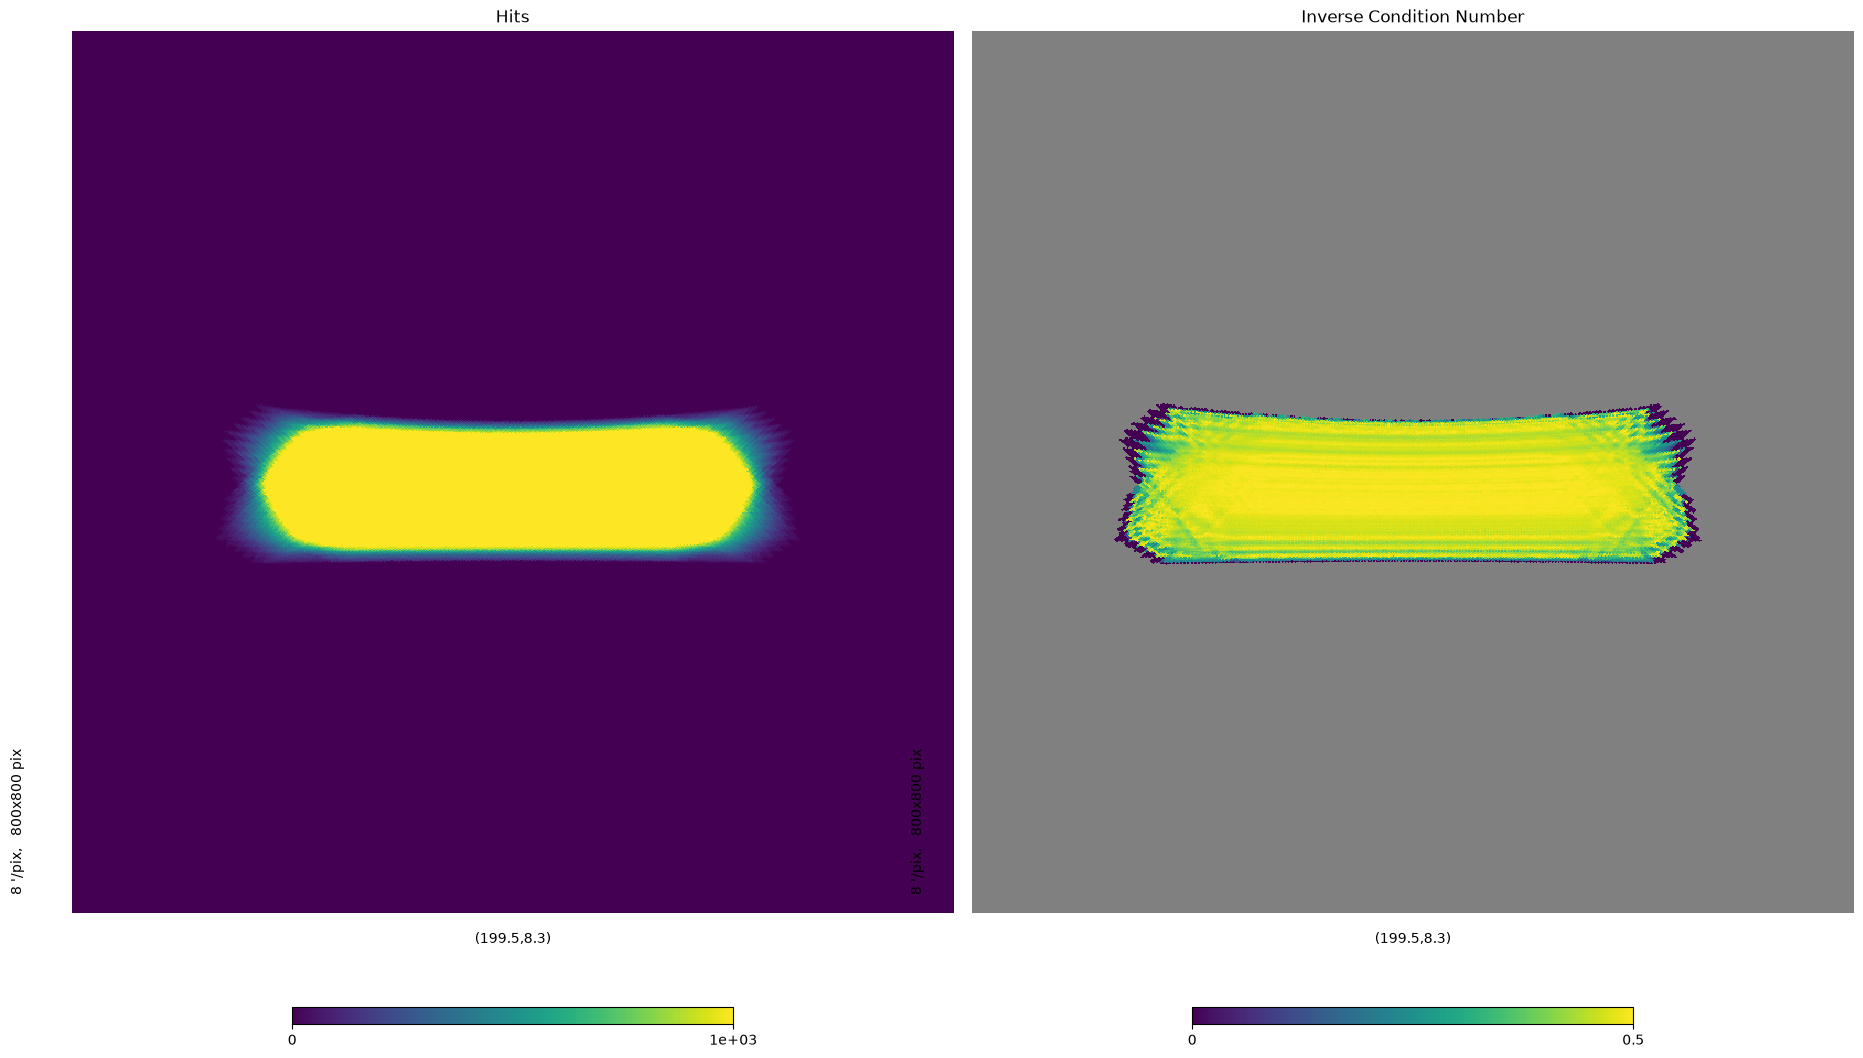

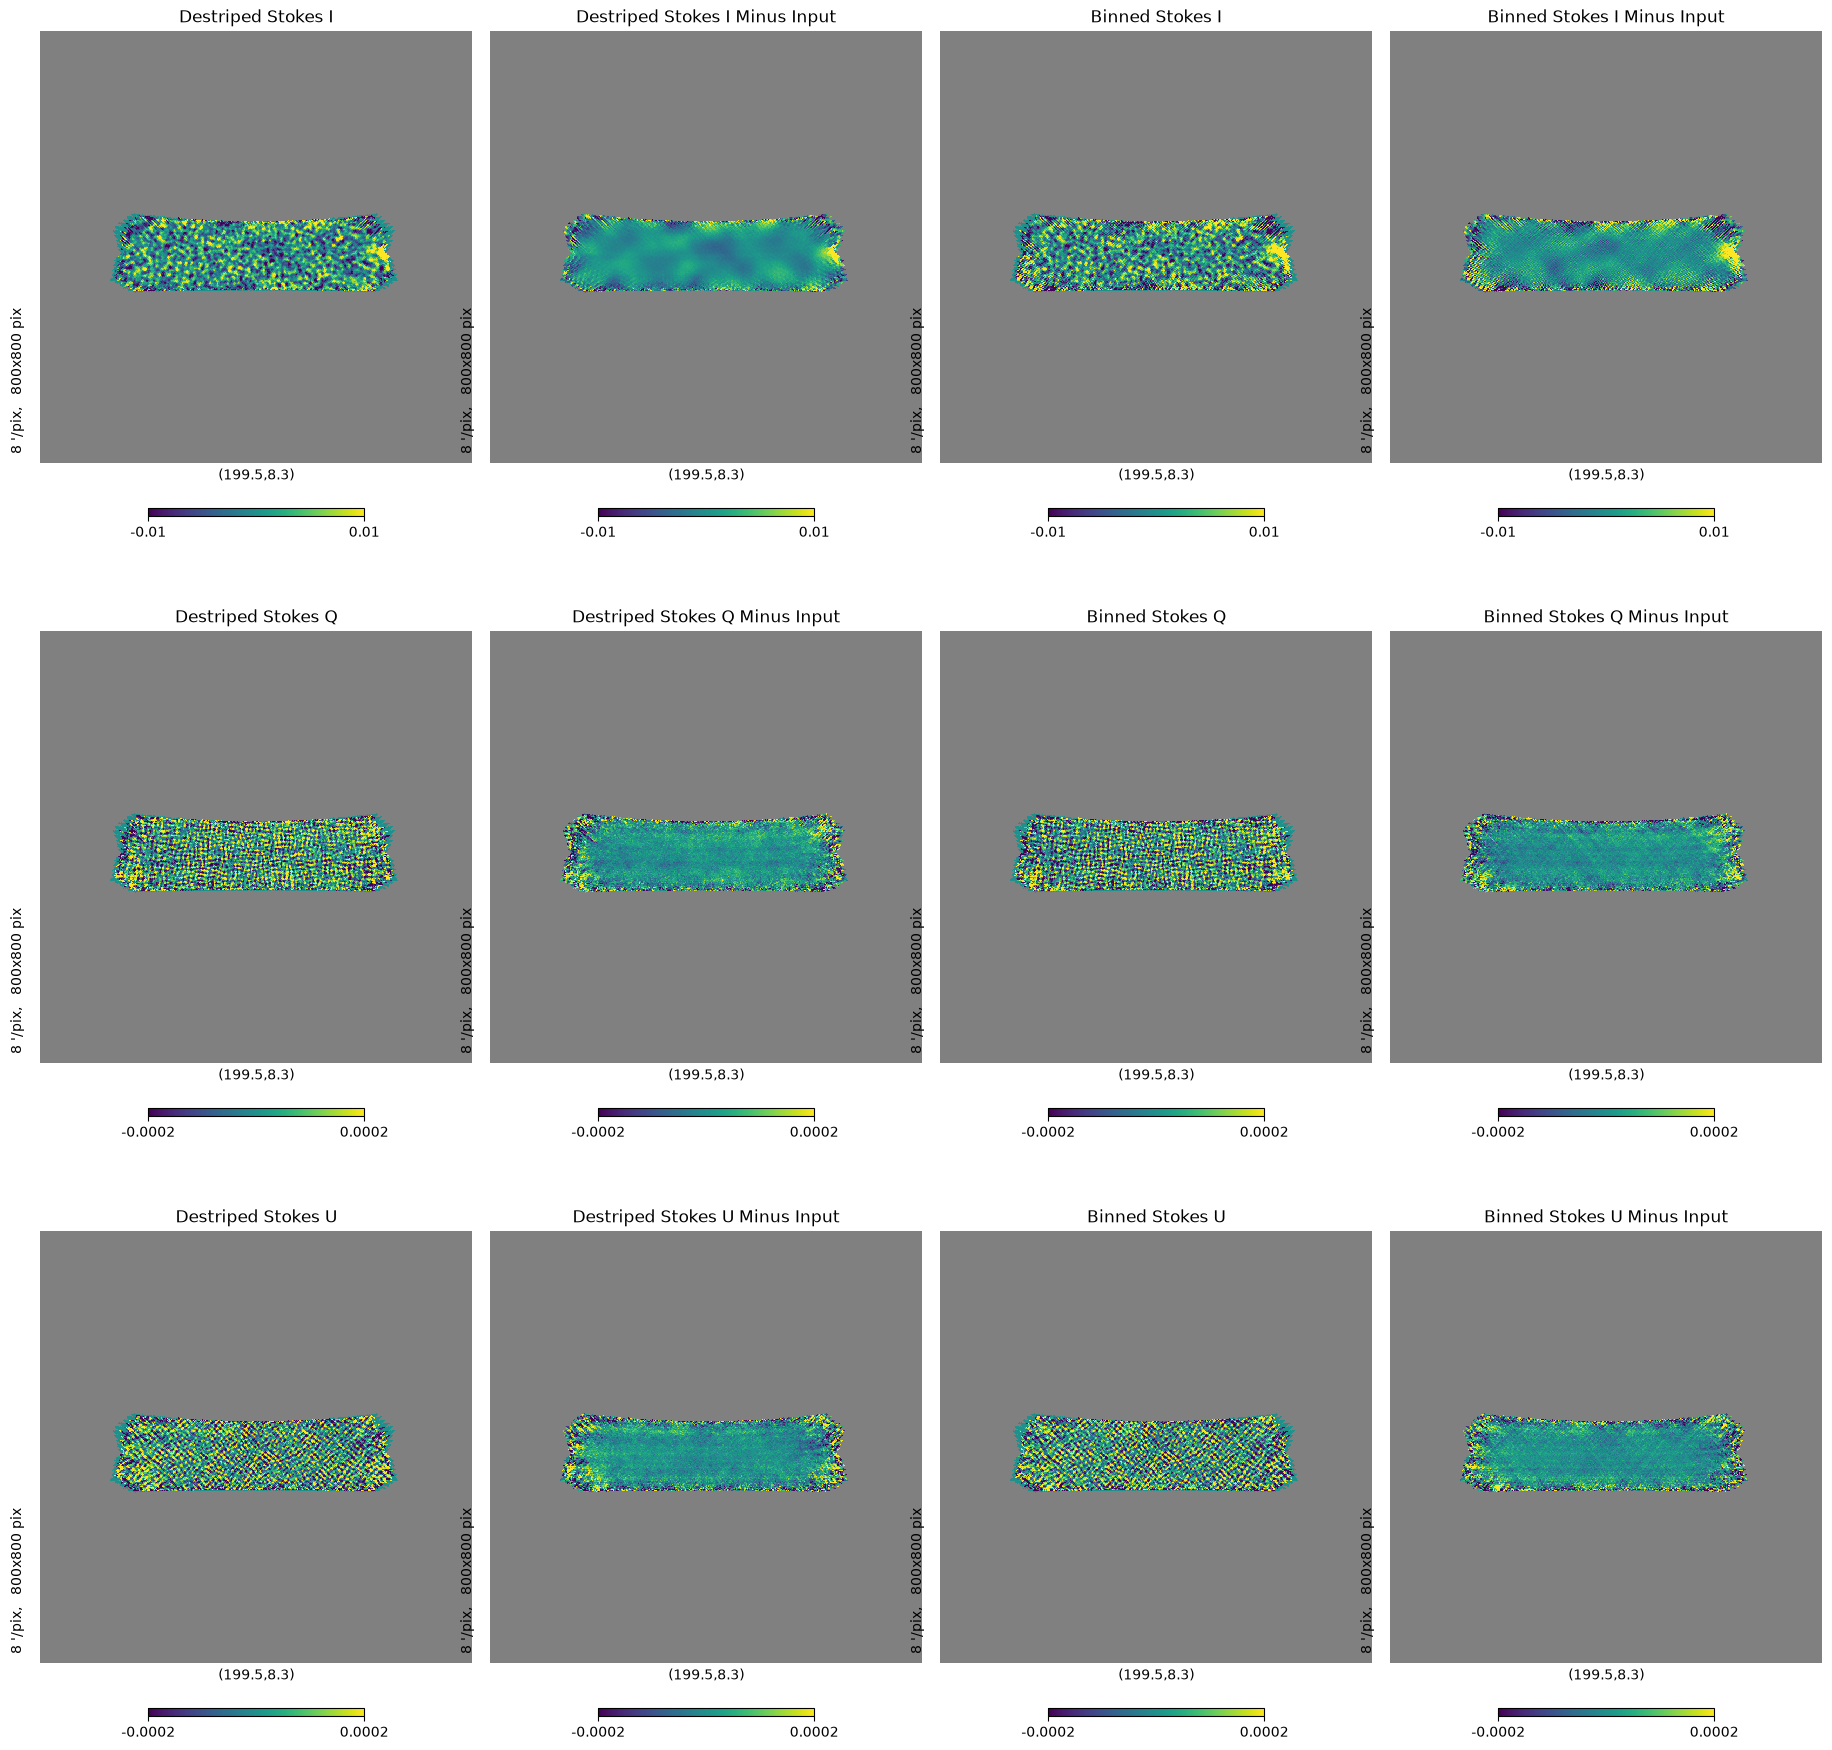

In [5]:
# maps = read_map(os.path.join(out_dir, 'mapmaker_map.fits'), field=None)
# binmaps = read_map(os.path.join(out_dir, 'mapmaker_binmap.fits'), field=None)
# truth = read_map(os.path.join(out_dir, "fake_sky.fits"), field=None)
plot_maps(os.path.join(out_dir, 'mapmaker'), truth=os.path.join(out_dir, "fake_sky.fits"))